<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/24_CNN_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN
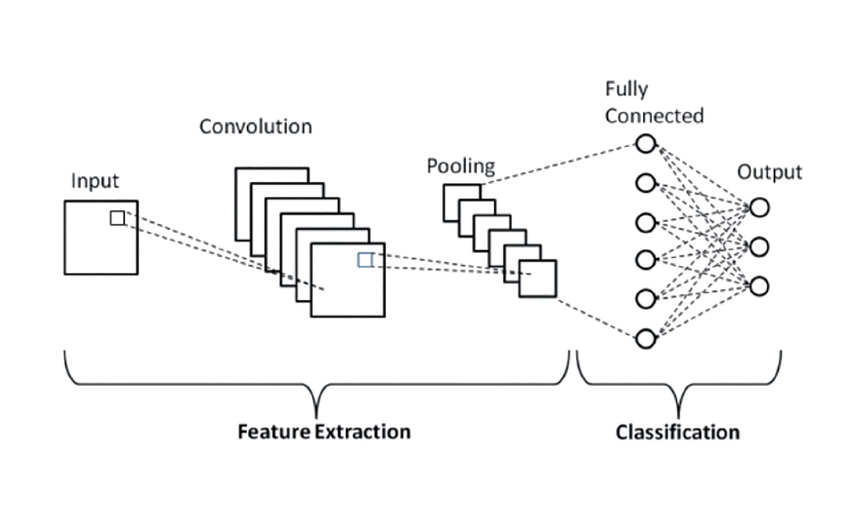

## 흑백 이미지 분류

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


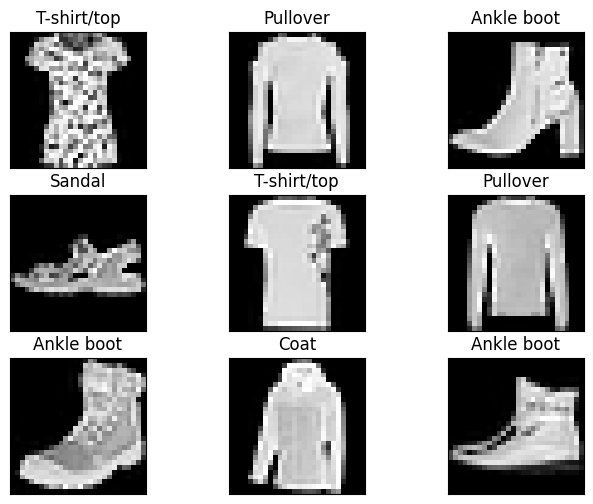

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ['T-shirt/top', 'Trouser', 'Pullover',
'Dress', 'Coat', 'Sandal',
'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
samples = np.random.randint(len(X_train), size=9)

plt.figure(figsize = (8,6))
for i , idx in enumerate(samples):
  plt.subplot(3,3,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(X_train[idx], cmap = 'gray')
  plt.title(class_names[y_train[idx]])

plt.show()

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(42000, 28, 28) (42000,)
(18000, 28, 28) (18000,)


In [4]:
import numpy as np

X_train = X_train.astype('float32') / 255.
X_val = X_val.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

print(np.max(X_train), np.min(X_train))

1.0 0.0


In [5]:
print('X_train : ', X_train.shape)
print('X_val : ', X_val.shape)
print('X_test : ', X_test.shape)

X_train :  (42000, 28, 28)
X_val :  (18000, 28, 28)
X_test :  (10000, 28, 28)


In [6]:
import tensorflow as tf
X_train = X_train[..., tf.newaxis]
X_val = X_val[..., tf.newaxis]
X_test = X_test[..., tf.newaxis]
print('X_train : ', X_train.shape)
print('X_val : ', X_val.shape)
print('X_test : ', X_test.shape)

X_train :  (42000, 28, 28, 1)
X_val :  (18000, 28, 28, 1)
X_test :  (10000, 28, 28, 1)


In [7]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model():
  model = keras.Sequential()
  model.add(layers.Conv2D(filters=16, kernel_size= 3,
                          strides=(1, 1), padding='same', activation='relu',
                          input_shape=(28, 28, 1)))
  model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))
  model.add(layers.Conv2D(filters=32, kernel_size=3, strides=(1,1), padding='same',
                          activation='relu'))
  model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dense(10,activation='softmax'))
  return model

In [8]:
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=adam, loss='sparse_categorical_crossentropy', metrics=['acc'])

In [10]:
EPOCHS = 30
BATCH_SIZE=64
history = model.fit(X_train, y_train, epochs = EPOCHS, batch_size=BATCH_SIZE, validation_data = (X_val, y_val),
                    verbose=1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.8045 - loss: 0.5564 - val_acc: 0.8682 - val_loss: 0.3714
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8715 - loss: 0.3586 - val_acc: 0.8800 - val_loss: 0.3371
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8886 - loss: 0.3112 - val_acc: 0.8958 - val_loss: 0.2907
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8984 - loss: 0.2809 - val_acc: 0.8989 - val_loss: 0.2823
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9063 - loss: 0.2574 - val_acc: 0.8958 - val_loss: 0.2823
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.9125 - loss: 0.2396 - val_acc: 0.9043 - val_loss: 0.2609
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9168 - loss: 0.2278 - val_acc: 0.9027 - val_loss: 0.2682
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9212 - loss: 0.2164 - val_acc: 0.9094 - val_loss: 0.2508
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - a

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(26,8))
  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Main Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Error')
  plt.plot(hist['epoch'], hist['val_loss'], label='Val Error')
  plt

  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['acc'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_acc'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

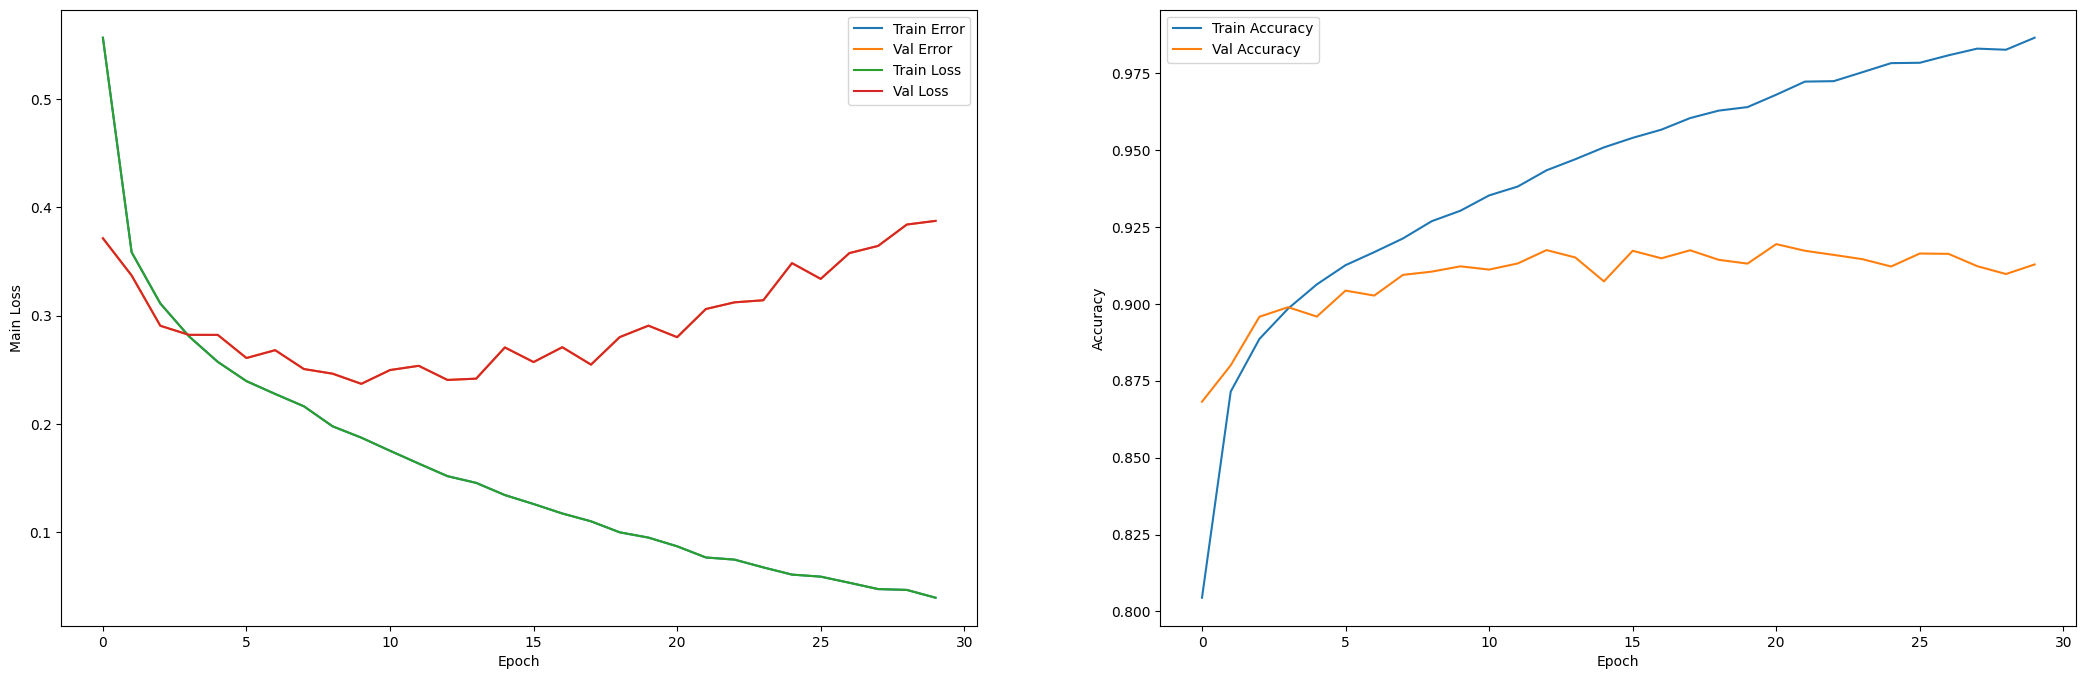

In [12]:
plot_history(history)

## Dropout

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

def build_dropout_model():
  model = keras.Sequential()

  model.add(layers.Conv2D(filters=16, kernel_size=3, strides=(1, 1), padding='same', activation='relu',
                          input_shape=(28, 28, 1)))
  model.add(layers.MaxPool2D(pool_size=(2,2), strides=2))
  model.add(layers.Dropout(0.2))

  model.add(layers.Conv2D(filters=32, kernel_size=3,
                          strides=(1,1), padding='same', activation='relu'))
  model.add(layers.MaxPool2D(pool_size=(2,2), strides=2))
  model.add(layers.Dropout(0.2))

  model.add(layers.Conv2D(filters=64, kernel_size=3,
                          strides=(1,1), padding='same', activation = 'relu'))
  model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))
  model.add(layers.Dropout(0.2))

  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation = 'relu'))
  model.add(layers.Dense(10, activation = 'softmax'))
  return model

In [14]:
model = build_dropout_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,874 (237.79 KB)

 Trainable params: 60,874 (237.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
y_train = y_train.reshape(-1)
y_val = y_val.reshape(-1)

In [16]:
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['acc'])


In [17]:
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(X_train, y_train, epochs = EPOCHS, batch_size = BATCH_SIZE,
                    validation_data = (X_val, y_val),
                    verbose = 1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - acc: 0.7303 - loss: 0.7229 - val_acc: 0.8420 - val_loss: 0.4561
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8333 - loss: 0.4540 - val_acc: 0.8569 - val_loss: 0.3948
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8548 - loss: 0.3967 - val_acc: 0.8791 - val_loss: 0.3335
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8641 - loss: 0.3643 - val_acc: 0.8858 - val_loss: 0.3211
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8728 - loss: 0.3387 - val_acc: 0.8964 - val_loss: 0.2840
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8841 - loss: 0.3161 - val_acc: 0.8964 - val_loss: 0.2788
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.8860 - loss: 0.3051 - val_acc: 0.8964 - val_loss: 0.2770
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.8920 - loss: 0.2897 - val_acc: 0.9012 - val_loss: 0.2656
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - 

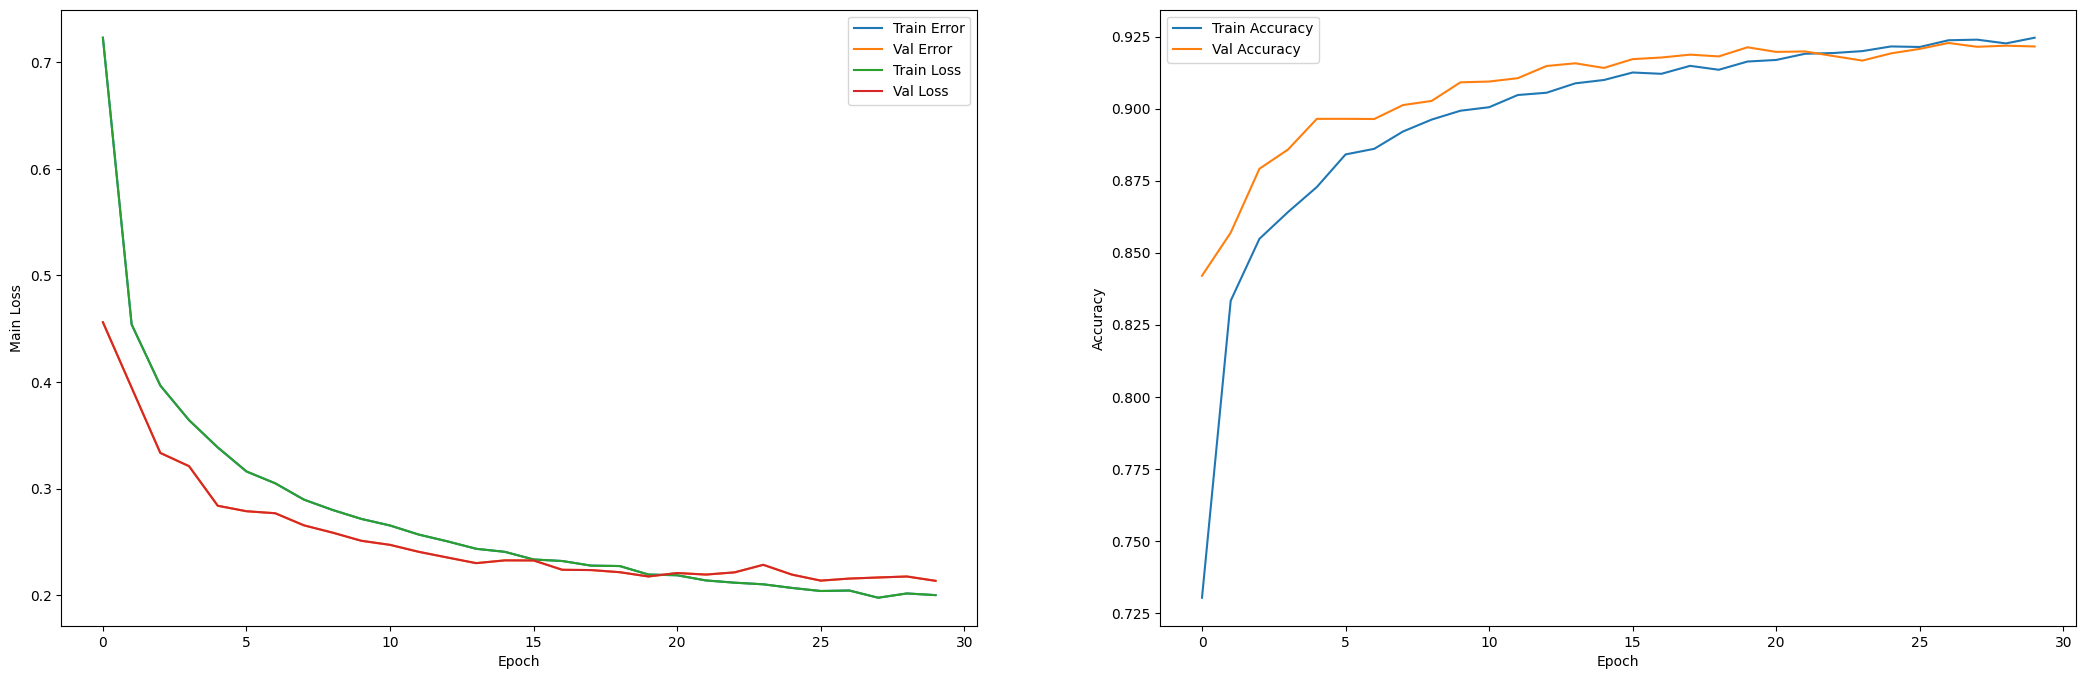

In [18]:
plot_history(history)

In [19]:
y_pred = model.predict(X_test)
y_pred_argmax= np.argmax(y_pred, axis=1)

y_pred_argmax[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [22]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
def print_score(y_test, y_pred):
  print('accuracy: %.3f' % (accuracy_score(y_test, y_pred)))
  print('precision: %.3f' % (precision_score(y_test, y_pred,
                                             average='macro')))
  print('recall_score: %.3f' % (recall_score(y_test, y_pred,
                                             average='macro')))
  print('f1_score: %.3f' % (f1_score(y_test, y_pred,
                                     average='macro')))

In [23]:
print_score(y_test, y_pred_argmax)

accuracy: 0.907
precision: 0.906
recall_score: 0.907
f1_score: 0.907


## 다중분류

In [24]:
model2 = build_dropout_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['acc'])

In [26]:
EPOCHS = 30
BATCH_SIZE = 64
history = model.fit(X_train, y_train, epochs=EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data= (X_val, y_val),
                    verbose=1)

Epoch 1/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9871 - loss: 0.0370 - val_acc: 0.9087 - val_loss: 0.4300
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9864 - loss: 0.0386 - val_acc: 0.9110 - val_loss: 0.4041
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9896 - loss: 0.0305 - val_acc: 0.9140 - val_loss: 0.4271
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9888 - loss: 0.0320 - val_acc: 0.9106 - val_loss: 0.4356
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc: 0.9892 - loss: 0.0302 - val_acc: 0.9088 - val_loss: 0.4579
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9899 - loss: 0.0289 - val_acc: 0.9134 - val_loss: 0.4614
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9895 - loss: 0.0293 - val_acc: 0.9071 - val_loss: 0.4972
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - acc: 0.9919 - loss: 0.0228 - val_acc: 0.9137 - val_loss: 0.4963
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - ac

In [27]:
y_pred= model.predict(X_test)
y_pred[:1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[5.4612883e-16, 7.2792742e-30, 7.6539328e-18, 1.2506339e-25,
        2.7379844e-21, 3.2647114e-13, 2.9166808e-22, 5.7847234e-11,
        4.4420777e-17, 1.0000000e+00]], dtype=float32)

In [28]:
y_pred_argmax = np.argmax(y_pred, axis=1)
print_score(y_test, y_pred_argmax)

accuracy: 0.902
precision: 0.903
recall_score: 0.902
f1_score: 0.901
